# Geometry of Quadratic Forms

Section 7.4.4 reveals the **geometric structure** behind quadratic forms. Given a positive definite symmetric matrix $\mathbf{A}$, the function

$$f(\mathbf{x}) = \mathbf{x}^T \mathbf{A} \mathbf{x}$$

has **ellipsoidal level sets**. Using the eigendecomposition $\mathbf{A} = \mathbf{U} \boldsymbol{\Lambda} \mathbf{U}^T$, we can write:

$$f(\mathbf{x}) = \mathbf{x}^T \mathbf{U} \boldsymbol{\Lambda} \mathbf{U}^T \mathbf{x} = \mathbf{y}^T \boldsymbol{\Lambda} \mathbf{y} = \sum_{i=1}^n \lambda_i y_i^2$$

where $\mathbf{y} = \mathbf{U}^T \mathbf{x}$ are the **rotated coordinates**. This reveals that:

- **Eigenvectors** $\mathbf{u}_i$ determine the **orientation** of the ellipsoid
- **Eigenvalues** $\lambda_i$ determine how **elongated** it is along each axis
- The semi-axes of the ellipse satisfy $a_i = \frac{1}{\sqrt{\lambda_i}}$

### Real-World Scenario: Protein Binding Affinity

In drug discovery, a candidate molecule's **binding affinity** to a target protein depends on multiple molecular descriptors (e.g., hydrophobicity, molecular weight, charge). The energy landscape around an optimal binding configuration forms a quadratic surface — understanding its geometry tells us which molecular properties matter most and how tightly constrained the design space is.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

---
## 1. From Eigendecomposition to Ellipsoids

The key insight from Section 7.4.4: for a symmetric positive definite matrix $\mathbf{A} = \mathbf{U} \boldsymbol{\Lambda} \mathbf{U}^T$, the level set

$$\{\mathbf{x} : \mathbf{x}^T \mathbf{A} \mathbf{x} = r\}$$

is an **ellipsoid**. In 2D, after the change of variables $\mathbf{y} = \mathbf{U}^T \mathbf{x}$:

$$\lambda_1 y_1^2 + \lambda_2 y_2^2 = r$$

This is the equation of an ellipse with semi-axes $a = \sqrt{r / \lambda_1}$ and $b = \sqrt{r / \lambda_2}$.

Let's build this step by step.

In [2]:
# Define a positive definite symmetric matrix
A = np.array([[5, 2],
              [2, 2]])

# Eigendecomposition: A = U Λ U^T
eigenvalues, U = np.linalg.eigh(A)
Lambda = np.diag(eigenvalues)

print("A =")
print(A)
print(f"\nEigenvalues: λ₁ = {eigenvalues[0]:.3f}, λ₂ = {eigenvalues[1]:.3f}")
print(f"\nEigenvectors (columns of U):")
print(f"  u₁ = [{U[0,0]:.3f}, {U[1,0]:.3f}]")
print(f"  u₂ = [{U[0,1]:.3f}, {U[1,1]:.3f}]")
print(f"\nVerify A = U Λ Uᵀ: {np.allclose(A, U @ Lambda @ U.T)}")
print(f"Verify U is orthogonal (UᵀU = I): {np.allclose(U.T @ U, np.eye(2))}")

A =
[[5 2]
 [2 2]]

Eigenvalues: λ₁ = 1.000, λ₂ = 6.000

Eigenvectors (columns of U):
  u₁ = [0.447, -0.894]
  u₂ = [-0.894, -0.447]

Verify A = U Λ Uᵀ: True
Verify U is orthogonal (UᵀU = I): True


In [4]:
# For a level set x^T A x = r, the semi-axes are sqrt(r / λ_i)
r = 1.0
semi_axes = np.sqrt(r / eigenvalues)

print(f"Level set: x^T A x = {r}")
print(f"\nSemi-axis along u₁: a₁ = √(r/λ₁) = √({r}/{eigenvalues[0]:.3f}) = {semi_axes[0]:.3f}")
print(f"Semi-axis along u₂: a₂ = √(r/λ₂) = √({r}/{eigenvalues[1]:.3f}) = {semi_axes[1]:.3f}")
print(f"\nThe larger eigenvalue → shorter semi-axis (tighter constraint)")
print(f"The smaller eigenvalue → longer semi-axis (more freedom)")
print(f"\nAspect ratio: {max(semi_axes)/min(semi_axes):.2f} (condition number √κ = √{eigenvalues[-1]/eigenvalues[0]:.2f} = {np.sqrt(eigenvalues[-1]/eigenvalues[0]):.2f})")

Level set: x^T A x = 1.0

Semi-axis along u₁: a₁ = √(r/λ₁) = √(1.0/1.000) = 1.000
Semi-axis along u₂: a₂ = √(r/λ₂) = √(1.0/6.000) = 0.408

The larger eigenvalue → shorter semi-axis (tighter constraint)
The smaller eigenvalue → longer semi-axis (more freedom)

Aspect ratio: 2.45 (condition number √κ = √6.00 = 2.45)


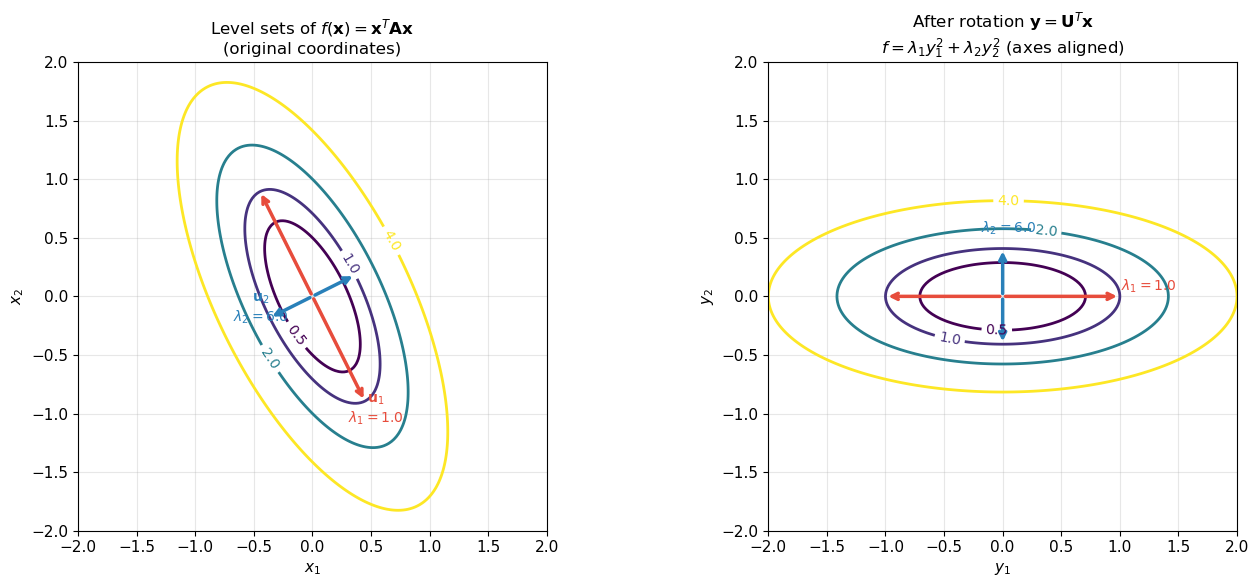

Left: ellipses tilted along eigenvectors.
Right: after rotating into the eigenbasis, the ellipses align with the axes.
       Larger eigenvalue (λ₂=6.0) → shorter axis → tighter constraint.


In [5]:
# Visualize: level sets with eigenvectors
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Create grid
t = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(t, t)

# Compute f(x) = x^T A x at each grid point
Z = A[0,0]*X**2 + (A[0,1]+A[1,0])*X*Y + A[1,1]*Y**2

# --- Left: Original coordinates ---
ax = axes[0]
levels = [0.5, 1, 2, 4]
cs = ax.contour(X, Y, Z, levels=levels, cmap='viridis', linewidths=2)
ax.clabel(cs, inline=True, fontsize=10, fmt='%.1f')

# Draw eigenvectors scaled by semi-axes for r=1
colors = ['#e74c3c', '#2980b9']
for i in range(2):
    ev = U[:, i] * semi_axes[i]
    ax.annotate('', xy=ev, xytext=[0, 0],
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=2.5))
    ax.annotate('', xy=-ev, xytext=[0, 0],
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=2.5))
    label_pos = ev * 1.2
    ax.text(label_pos[0], label_pos[1],
            f'$\\mathbf{{u}}_{i+1}$\n$\\lambda_{i+1}={eigenvalues[i]:.1f}$',
            fontsize=10, color=colors[i], ha='center', fontweight='bold')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Level sets of $f(\\mathbf{x}) = \\mathbf{x}^T \\mathbf{A} \\mathbf{x}$\n(original coordinates)', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

# --- Right: Rotated coordinates y = U^T x ---
ax = axes[1]
Z_diag = eigenvalues[0]*X**2 + eigenvalues[1]*Y**2
cs = ax.contour(X, Y, Z_diag, levels=levels, cmap='viridis', linewidths=2)
ax.clabel(cs, inline=True, fontsize=10, fmt='%.1f')

# Axes are now aligned with coordinate axes
for i, (axis_vec, color) in enumerate(zip([np.array([1,0]), np.array([0,1])], colors)):
    ev = axis_vec * semi_axes[i]
    ax.annotate('', xy=ev, xytext=[0, 0],
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.annotate('', xy=-ev, xytext=[0, 0],
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    label_pos = ev * 1.2
    ax.text(label_pos[0] + 0.05, label_pos[1] + 0.05,
            f'$\\lambda_{i+1}={eigenvalues[i]:.1f}$',
            fontsize=10, color=color, ha='center', fontweight='bold')

ax.set_xlabel('$y_1$')
ax.set_ylabel('$y_2$')
ax.set_title('After rotation $\\mathbf{y} = \\mathbf{U}^T \\mathbf{x}$\n$f = \\lambda_1 y_1^2 + \\lambda_2 y_2^2$ (axes aligned)', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

plt.tight_layout()
plt.show()

print("Left: ellipses tilted along eigenvectors.")
print("Right: after rotating into the eigenbasis, the ellipses align with the axes.")
print("       Larger eigenvalue (λ₂=6.0) → shorter axis → tighter constraint.")

---
## 2. The Three-Step Decomposition: Rotate, Scale, Rotate Back

From Section 7.4.3, multiplying by $\mathbf{A} = \mathbf{U} \boldsymbol{\Lambda} \mathbf{U}^T$ can be decomposed as:

1. **Rotate** into the eigenbasis: $\mathbf{U}^T \mathbf{x}$ (align with eigenvectors)
2. **Scale** each axis by $\lambda_i$: $\boldsymbol{\Lambda} (\mathbf{U}^T \mathbf{x})$
3. **Rotate back**: $\mathbf{U} (\boldsymbol{\Lambda} \mathbf{U}^T \mathbf{x})$

Let's visualize this transformation on the unit circle.

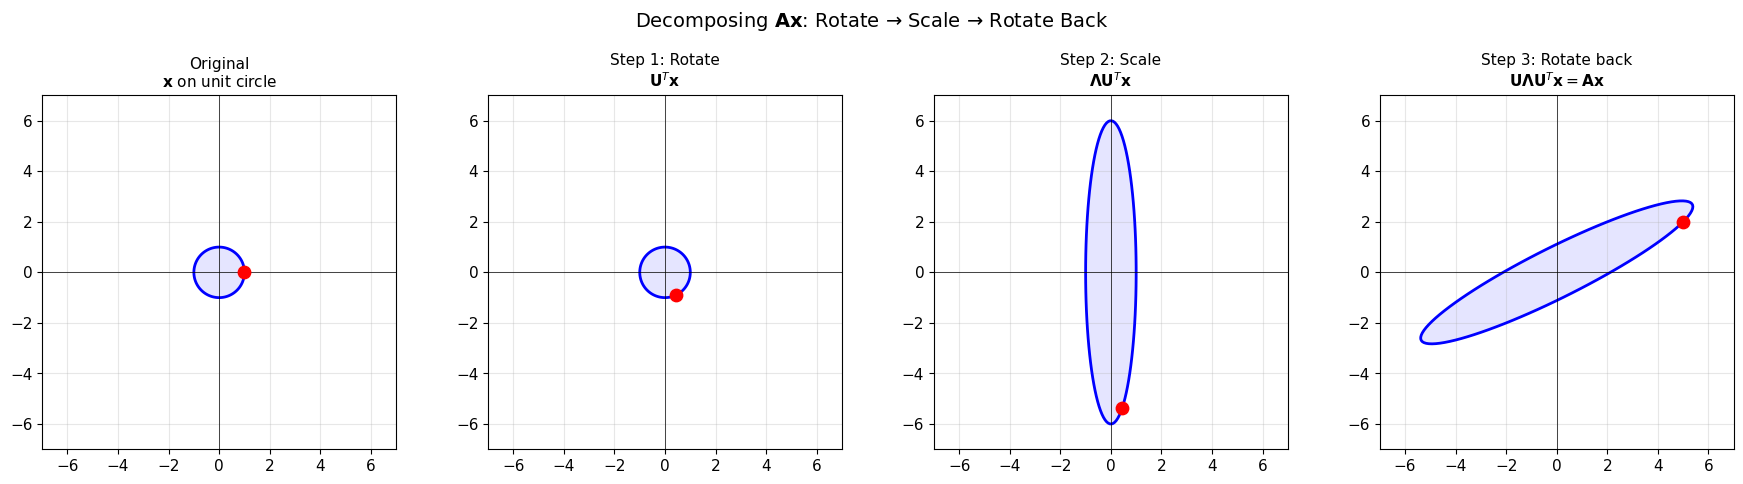

In [6]:
# Generate points on the unit circle
theta = np.linspace(0, 2*np.pi, 100)
circle = np.array([np.cos(theta), np.sin(theta)])  # 2 x 100

# Apply each step
step1 = U.T @ circle          # Rotate into eigenbasis
step2 = Lambda @ step1        # Scale
step3 = U @ step2             # Rotate back (= A @ circle)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

titles = [
    'Original\n$\\mathbf{x}$ on unit circle',
    'Step 1: Rotate\n$\\mathbf{U}^T \\mathbf{x}$',
    'Step 2: Scale\n$\\boldsymbol{\\Lambda} \\mathbf{U}^T \\mathbf{x}$',
    'Step 3: Rotate back\n$\\mathbf{U} \\boldsymbol{\\Lambda} \\mathbf{U}^T \\mathbf{x} = \\mathbf{A}\\mathbf{x}$'
]
data = [circle, step1, step2, step3]

for ax, d, title in zip(axes, data, titles):
    ax.plot(d[0], d[1], 'b-', linewidth=2)
    ax.fill(d[0], d[1], alpha=0.1, color='blue')
    # Mark a reference point to show the transformation
    ax.scatter([d[0, 0]], [d[1, 0]], c='red', s=80, zorder=5)
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', lw=0.5)
    ax.axvline(x=0, color='black', lw=0.5)
    ax.set_xlim(-7, 7)
    ax.set_ylim(-7, 7)

plt.suptitle('Decomposing $\\mathbf{A}\\mathbf{x}$: Rotate → Scale → Rotate Back', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Eigenvalues Control the Ellipsoid Shape

The **condition number** $\kappa = \lambda_{\max} / \lambda_{\min}$ tells us how elongated the ellipsoid is:

| Condition number | Shape | Optimization difficulty |
|:---:|:---:|:---:|
| $\kappa = 1$ | Circle (sphere) | Easy — same curvature everywhere |
| $\kappa \approx 10$ | Moderate ellipse | Medium |
| $\kappa \gg 1$ | Very elongated | Hard — narrow valley in some directions |

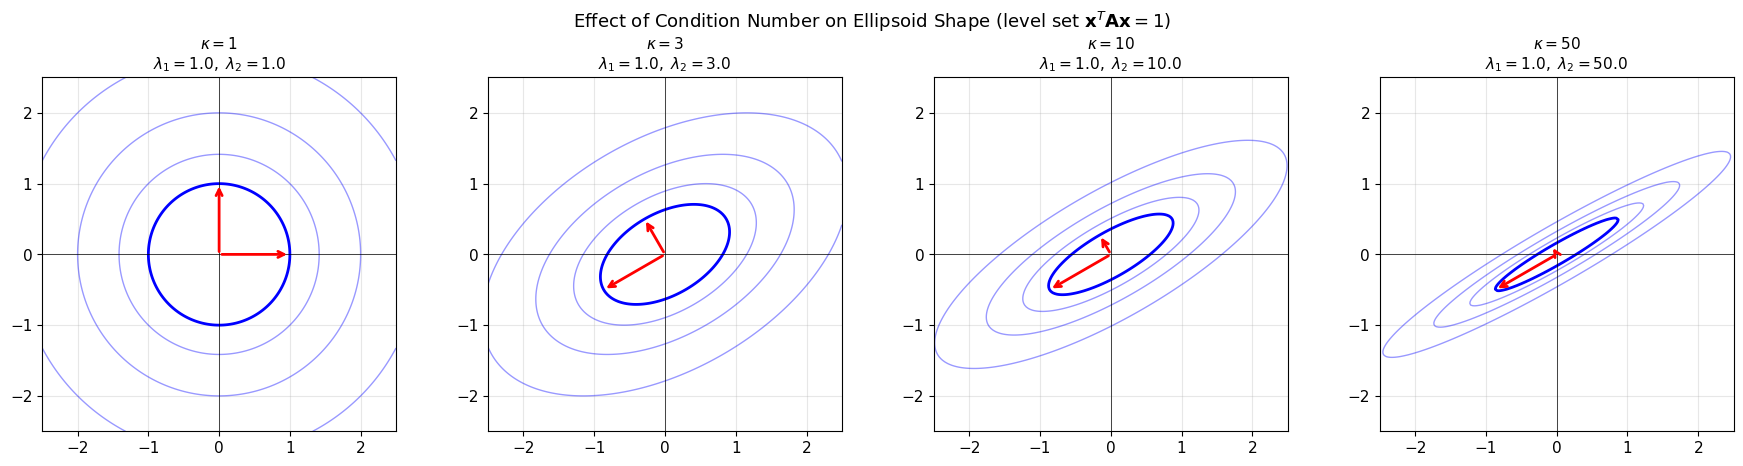

Higher condition number → more elongated ellipse → harder optimization landscape.
At κ=1 (all eigenvalues equal), level sets are perfect circles.


In [7]:
# Vary the condition number and see the effect on ellipse shape
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

condition_numbers = [1, 3, 10, 50]

for ax, kappa in zip(axes, condition_numbers):
    # Create matrix with desired condition number
    # Use eigenvalues [1, kappa] rotated by 30 degrees
    angle = np.radians(30)
    R = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])
    A_k = R @ np.diag([1, kappa]) @ R.T
    
    # Compute quadratic form on grid
    t = np.linspace(-2.5, 2.5, 200)
    X, Y = np.meshgrid(t, t)
    Z = A_k[0,0]*X**2 + (A_k[0,1]+A_k[1,0])*X*Y + A_k[1,1]*Y**2
    
    # Plot level set at r=1
    ax.contour(X, Y, Z, levels=[1], colors='blue', linewidths=2)
    ax.contour(X, Y, Z, levels=[2, 4, 8], colors='blue', linewidths=1, alpha=0.4)
    
    # Draw eigenvectors
    evals_k, evecs_k = np.linalg.eigh(A_k)
    for i in range(2):
        ev = evecs_k[:, i] / np.sqrt(evals_k[i])  # length = semi-axis
        ax.annotate('', xy=ev, xytext=[0, 0],
                    arrowprops=dict(arrowstyle='->', color='red', lw=2))
    
    ax.set_title(f'$\\kappa = {kappa}$\n$\\lambda_1={evals_k[0]:.1f},\ \\lambda_2={evals_k[1]:.1f}$', fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.axhline(y=0, color='black', lw=0.5)
    ax.axvline(x=0, color='black', lw=0.5)

plt.suptitle('Effect of Condition Number on Ellipsoid Shape (level set $\\mathbf{x}^T \\mathbf{A} \\mathbf{x} = 1$)', fontsize=13)
plt.tight_layout()
plt.show()

print("Higher condition number → more elongated ellipse → harder optimization landscape.")
print("At κ=1 (all eigenvalues equal), level sets are perfect circles.")

---
## 4. Connection to Gaussian Distributions

For a Gaussian $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, the exponent is a quadratic form using the **precision matrix** $\mathbf{A} = \boldsymbol{\Sigma}^{-1}$:

$$p(\mathbf{x}) \propto \exp\!\left(-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})\right)$$

The contours of constant probability are level sets of this quadratic form — they are **ellipses** centered at $\boldsymbol{\mu}$.

From Section 7.4.4: since $\mathbf{A} = \boldsymbol{\Sigma}^{-1}$, small eigenvalues $\lambda_i$ of the precision matrix correspond to directions of **high variance** (the ellipse is *wide* in those directions).

In [8]:
# Protein binding affinity: two molecular descriptors
# x1 = hydrophobicity score, x2 = molecular weight (scaled)
mu = np.array([3.5, 2.0])  # optimal binding point

# Covariance: hydrophobicity has more tolerance than molecular weight
# and they are correlated (heavier molecules tend to be more hydrophobic)
Sigma = np.array([[1.5, 0.8],
                  [0.8, 0.6]])

# Precision matrix (used in the quadratic form)
Sigma_inv = np.linalg.inv(Sigma)

# Eigendecomposition of the precision matrix
prec_eigenvalues, prec_eigenvectors = np.linalg.eigh(Sigma_inv)

# Eigendecomposition of the covariance matrix
cov_eigenvalues, cov_eigenvectors = np.linalg.eigh(Sigma)

print("Protein Binding Affinity Model")
print("=" * 50)
print(f"Optimal binding point μ = {mu}")
print(f"\nCovariance Σ (tolerance around optimum):")
print(Sigma)
print(f"\nPrecision Σ⁻¹ (used in quadratic form):")
print(Sigma_inv.round(3))
print(f"\nPrecision eigenvalues: {prec_eigenvalues.round(3)}")
print(f"Covariance eigenvalues: {cov_eigenvalues.round(3)}")
print(f"\nNote: precision eigenvalues = 1 / covariance eigenvalues:")
print(f"  1/{cov_eigenvalues[0]:.3f} = {1/cov_eigenvalues[0]:.3f} ≈ {prec_eigenvalues[1]:.3f}")
print(f"  1/{cov_eigenvalues[1]:.3f} = {1/cov_eigenvalues[1]:.3f} ≈ {prec_eigenvalues[0]:.3f}")

Protein Binding Affinity Model
Optimal binding point μ = [3.5 2. ]

Covariance Σ (tolerance around optimum):
[[1.5 0.8]
 [0.8 0.6]]

Precision Σ⁻¹ (used in quadratic form):
[[ 2.308 -3.077]
 [-3.077  5.769]]

Precision eigenvalues: [0.508 7.569]
Covariance eigenvalues: [0.132 1.968]

Note: precision eigenvalues = 1 / covariance eigenvalues:
  1/0.132 = 7.569 ≈ 7.569
  1/1.968 = 0.508 ≈ 0.508


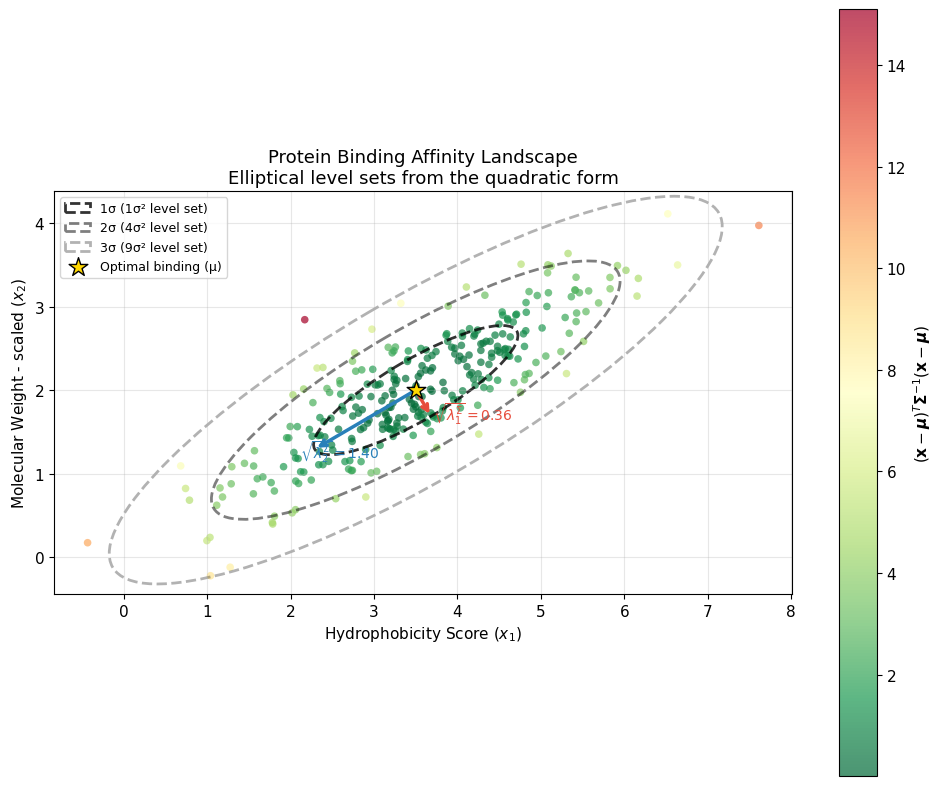

Each ellipse is a level set of (x-μ)ᵀ Σ⁻¹ (x-μ) = constant.
The eigenvectors of Σ set the ellipse orientation.
The eigenvalues of Σ set the ellipse widths (√λ = standard deviation along that direction).


In [9]:
# Generate synthetic binding data
n_compounds = 300
compounds = np.random.multivariate_normal(mu, Sigma, n_compounds)

# Compute binding scores (quadratic form = Mahalanobis distance squared)
def mahalanobis_sq(x, mu, Sigma_inv):
    d = x - mu
    return d @ Sigma_inv @ d

scores = np.array([mahalanobis_sq(x, mu, Sigma_inv) for x in compounds])

# Classify binding quality
fig, ax = plt.subplots(figsize=(10, 8))

# Plot compounds colored by binding score
scatter = ax.scatter(compounds[:, 0], compounds[:, 1], c=scores,
                     cmap='RdYlGn_r', s=30, alpha=0.7, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='$(\\mathbf{x}-\\boldsymbol{\\mu})^T \\boldsymbol{\\Sigma}^{-1} (\\mathbf{x}-\\boldsymbol{\\mu})$')

# Draw confidence ellipses (level sets of the quadratic form)
for n_std, alpha_val, label in [(1, 0.8, '1σ'), (2, 0.5, '2σ'), (3, 0.3, '3σ')]:
    # Semi-axes from covariance eigenvalues
    angle = np.degrees(np.arctan2(cov_eigenvectors[1, 1], cov_eigenvectors[0, 1]))
    width = 2 * n_std * np.sqrt(cov_eigenvalues[1])
    height = 2 * n_std * np.sqrt(cov_eigenvalues[0])
    ellipse = Ellipse(mu, width, height, angle=angle,
                      fill=False, color='black', linewidth=2, alpha=alpha_val,
                      linestyle='--', label=f'{label} ({n_std**2:.0f}σ² level set)')
    ax.add_patch(ellipse)

# Draw eigenvectors of the precision matrix
colors = ['#e74c3c', '#2980b9']
for i in range(2):
    # Scale eigenvectors by semi-axes of 1σ ellipse
    ev = cov_eigenvectors[:, i] * np.sqrt(cov_eigenvalues[i])
    ax.annotate('', xy=mu + ev, xytext=mu,
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=2.5))
    ax.text(mu[0] + ev[0]*1.15, mu[1] + ev[1]*1.15,
            f'$\\sqrt{{\\lambda_{i+1}^{{\\Sigma}}}}={np.sqrt(cov_eigenvalues[i]):.2f}$',
            fontsize=10, color=colors[i], fontweight='bold')

ax.scatter([mu[0]], [mu[1]], c='gold', s=200, marker='*', zorder=5,
           edgecolors='black', label='Optimal binding (μ)')

ax.set_xlabel('Hydrophobicity Score ($x_1$)')
ax.set_ylabel('Molecular Weight - scaled ($x_2$)')
ax.set_title('Protein Binding Affinity Landscape\nElliptical level sets from the quadratic form', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("Each ellipse is a level set of (x-μ)ᵀ Σ⁻¹ (x-μ) = constant.")
print("The eigenvectors of Σ set the ellipse orientation.")
print("The eigenvalues of Σ set the ellipse widths (√λ = standard deviation along that direction).")

---
## 5. Precision vs. Covariance: Dual Views

Since $\boldsymbol{\Sigma}^{-1} = \mathbf{U} \boldsymbol{\Lambda}_{\Sigma}^{-1} \mathbf{U}^T$, the eigenvalues of the precision matrix are **reciprocals** of those of the covariance:

| Direction | Covariance $\lambda_i^\Sigma$ | Precision $\lambda_i^{\Sigma^{-1}} = 1/\lambda_i^\Sigma$ | Interpretation |
|:---:|:---:|:---:|:---:|
| High variance | Large | Small | Loose constraint |
| Low variance | Small | Large | Tight constraint |

This is the insight from the text: *"small values of $\lambda_i$ [of the precision] correspond to directions where the posterior has low precision and hence high variance."*

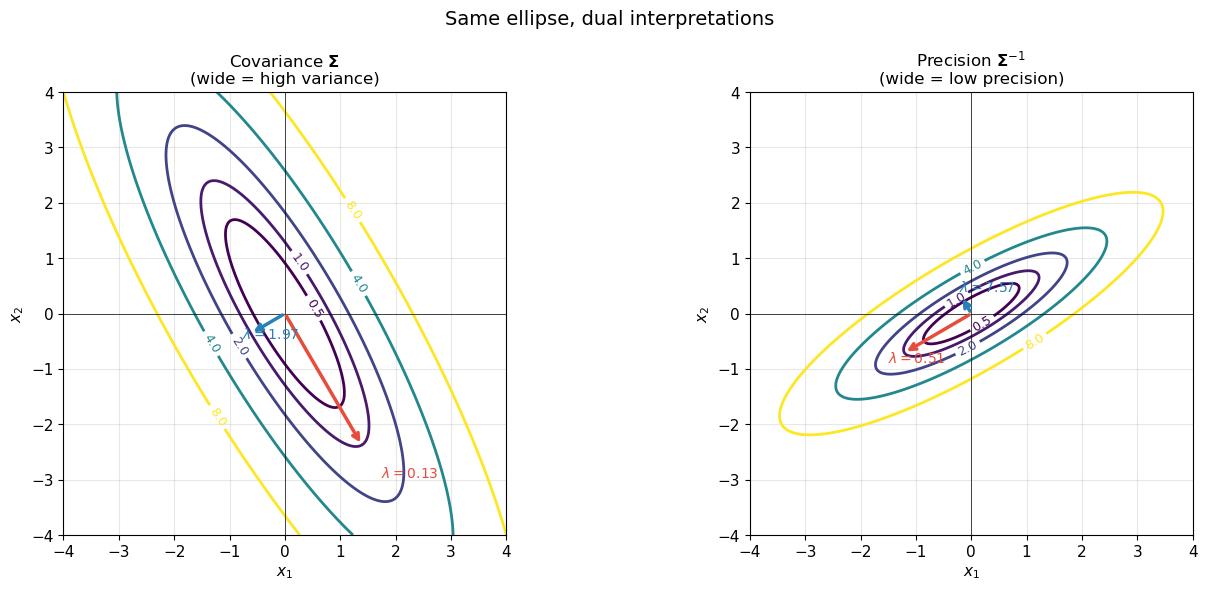

Both matrices share the same eigenvectors (same orientation).
But their eigenvalues are reciprocals: the 'wide' direction of Σ
becomes the 'narrow' direction of Σ⁻¹, and vice versa.


In [10]:
# Side-by-side: covariance ellipse vs precision ellipse
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, matrix, title, eigvals, eigvecs in [
    (axes[0], Sigma, 'Covariance $\\boldsymbol{\\Sigma}$\n(wide = high variance)', cov_eigenvalues, cov_eigenvectors),
    (axes[1], Sigma_inv, 'Precision $\\boldsymbol{\\Sigma}^{-1}$\n(wide = low precision)', prec_eigenvalues, prec_eigenvectors)
]:
    # Compute quadratic form
    t = np.linspace(-4, 4, 200)
    X, Y = np.meshgrid(t, t)
    Z = matrix[0,0]*X**2 + (matrix[0,1]+matrix[1,0])*X*Y + matrix[1,1]*Y**2

    cs = ax.contour(X, Y, Z, levels=[0.5, 1, 2, 4, 8], cmap='viridis', linewidths=2)
    ax.clabel(cs, inline=True, fontsize=9)

    # Draw eigenvectors
    for i in range(2):
        ev = eigvecs[:, i] / np.sqrt(eigvals[i])  # semi-axis length for r=1
        ax.annotate('', xy=ev, xytext=[0, 0],
                    arrowprops=dict(arrowstyle='->', color=colors[i], lw=2.5))
        ax.text(ev[0]*1.25, ev[1]*1.25,
                f'$\\lambda={eigvals[i]:.2f}$', fontsize=10, color=colors[i], fontweight='bold')

    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', lw=0.5)
    ax.axvline(x=0, color='black', lw=0.5)

plt.suptitle('Same ellipse, dual interpretations', fontsize=14)
plt.tight_layout()
plt.show()

print("Both matrices share the same eigenvectors (same orientation).")
print("But their eigenvalues are reciprocals: the 'wide' direction of Σ")
print("becomes the 'narrow' direction of Σ⁻¹, and vice versa.")

---
## 6. 3D Quadratic Form Surface and Its Level Sets

Let's visualize the full quadratic surface $f(\mathbf{x}) = \mathbf{x}^T \mathbf{A} \mathbf{x}$ in 3D, with the level-set ellipses shown as horizontal slices.

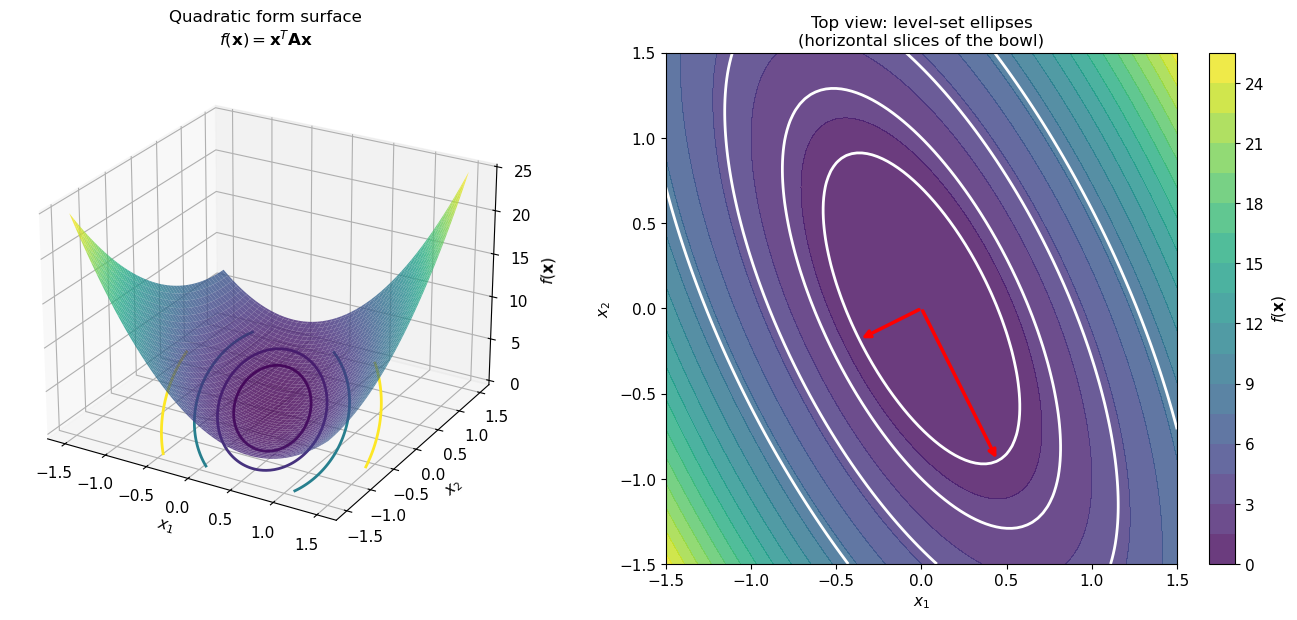

The bowl shape comes from positive definiteness (all eigenvalues > 0).
Each horizontal slice (fixed height) gives an elliptical level set.


In [11]:
A = np.array([[5, 2],
              [2, 2]])

t = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(t, t)
Z = A[0,0]*X**2 + (A[0,1]+A[1,0])*X*Y + A[1,1]*Y**2

fig = plt.figure(figsize=(14, 6))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, linewidth=0)

# Add level-set contours at the base
ax1.contour(X, Y, Z, levels=[1, 2, 4, 8], zdir='z', offset=0, cmap='viridis', linewidths=2)

ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(\\mathbf{x})$')
ax1.set_title('Quadratic form surface\n$f(\\mathbf{x}) = \\mathbf{x}^T \\mathbf{A} \\mathbf{x}$', fontsize=12)
ax1.view_init(elev=25, azim=-60)

# Top-down view (contour plot)
ax2 = fig.add_subplot(122)
cs = ax2.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.8)
ax2.contour(X, Y, Z, levels=[1, 2, 4, 8], colors='white', linewidths=2)
plt.colorbar(cs, ax=ax2, label='$f(\\mathbf{x})$')

# Draw eigenvectors
evals, evecs = np.linalg.eigh(A)
for i in range(2):
    ev = evecs[:, i] / np.sqrt(evals[i])  # semi-axis for r=1
    ax2.annotate('', xy=ev, xytext=[0, 0],
                arrowprops=dict(arrowstyle='->', color='red', lw=2.5))

ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_title('Top view: level-set ellipses\n(horizontal slices of the bowl)', fontsize=12)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print("The bowl shape comes from positive definiteness (all eigenvalues > 0).")
print("Each horizontal slice (fixed height) gives an elliptical level set.")

---
## 7. Application: Drug Design Space Exploration

Back to our biotech scenario. Suppose we've fit a quadratic model to predict binding affinity from three molecular descriptors: hydrophobicity ($x_1$), molecular weight ($x_2$), and polar surface area ($x_3$). The fitted precision matrix $\mathbf{A}$ determines which directions in descriptor space are tightly constrained vs. flexible.

By examining the eigenvalues, we can identify:
- **Rigid directions** (large $\lambda$): small deviations cause large affinity drops
- **Flexible directions** (small $\lambda$): can vary more without losing binding

In [12]:
# 3D protein binding model
mu_3d = np.array([3.5, 450, 80])  # optimal: hydrophobicity, MW (Da), PSA (Å²)
labels = ['Hydrophobicity', 'Molecular Weight (Da)', 'Polar Surface Area (Å²)']

# Covariance — how much each descriptor can vary
Sigma_3d = np.array([
    [0.50,  5.0,  1.0],   # hydrophobicity
    [5.0,  900.0, 30.0],  # MW
    [1.0,   30.0, 25.0],  # PSA
])

# Eigendecomposition of the covariance
cov_evals_3d, cov_evecs_3d = np.linalg.eigh(Sigma_3d)

# Precision matrix and its eigendecomposition
Prec_3d = np.linalg.inv(Sigma_3d)
prec_evals_3d, prec_evecs_3d = np.linalg.eigh(Prec_3d)

print("Drug Design Space Analysis")
print("=" * 60)
print(f"Optimal point μ = {mu_3d}")
print(f"\nPrincipal directions (eigenvectors of Σ):")
print(f"{'Direction':<12} {'σ (std dev)':<12} {'Interpretation'}")
print("-" * 60)
for i in range(2, -1, -1):
    std_dev = np.sqrt(cov_evals_3d[i])
    # Find dominant component
    dominant = np.argmax(np.abs(cov_evecs_3d[:, i]))
    print(f"  PC{3-i:<8} {std_dev:<12.2f} Mostly {labels[dominant]}")

print(f"\nPrecision eigenvalues (from Σ⁻¹):")
print(f"  {prec_evals_3d.round(4)}")
print(f"  = 1 / covariance eigenvalues: {(1/cov_evals_3d).round(4)}")

print(f"\nCondition number κ = {cov_evals_3d[-1]/cov_evals_3d[0]:.1f}")
print(f"  → Binding affinity is ~{cov_evals_3d[-1]/cov_evals_3d[0]:.0f}x more sensitive")
print(f"    in the tightest direction vs. the loosest.")

Drug Design Space Analysis
Optimal point μ = [  3.5 450.   80. ]

Principal directions (eigenvectors of Σ):
Direction    σ (std dev)  Interpretation
------------------------------------------------------------
  PC1        30.02        Mostly Molecular Weight (Da)
  PC2        4.90         Mostly Polar Surface Area (Å²)
  PC3        0.67         Mostly Hydrophobicity

Precision eigenvalues (from Σ⁻¹):
  [1.1000e-03 4.1700e-02 2.2587e+00]
  = 1 / covariance eigenvalues: [2.2587e+00 4.1700e-02 1.1000e-03]

Condition number κ = 2035.2
  → Binding affinity is ~2035x more sensitive
    in the tightest direction vs. the loosest.


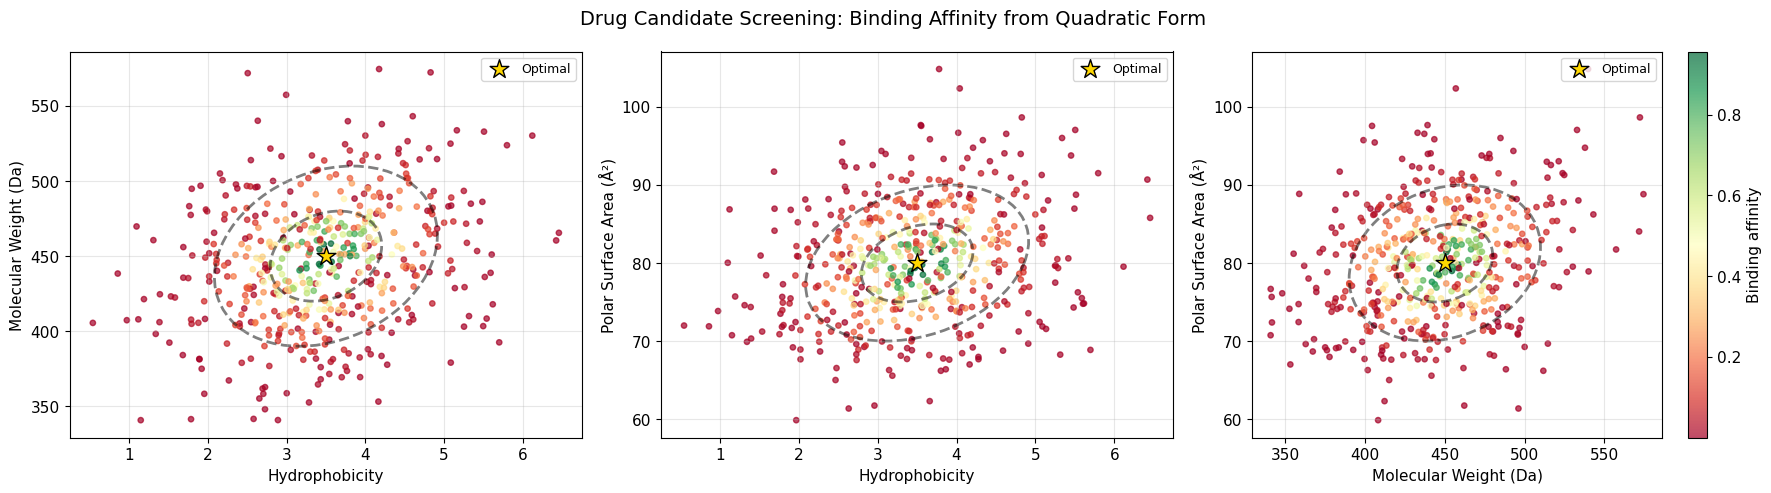


Top 5 candidate compounds:
Rank   Hydro    MW (Da)    PSA (Å²)   Affinity   Mahal²    
-------------------------------------------------------
1      3.42     454.5      79.0       0.9566     0.09      
2      3.56     458.3      79.8       0.9559     0.09      
3      3.41     444.7      78.6       0.9551     0.09      
4      3.47     457.9      79.4       0.9483     0.11      
5      3.69     451.0      81.4       0.9411     0.12      


In [13]:
# Generate candidate compounds and rank them
n_candidates = 500
candidates = np.random.multivariate_normal(mu_3d, Sigma_3d * 2, n_candidates)  # wider search

# Binding affinity = exp(-0.5 * Mahalanobis²)  (closer to 1 = better)
mah_sq = np.array([mahalanobis_sq(x, mu_3d, Prec_3d) for x in candidates])
affinity = np.exp(-0.5 * mah_sq)

# Visualize pairwise projections
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [(0, 1), (0, 2), (1, 2)]

for ax, (i, j) in zip(axes, pairs):
    scatter = ax.scatter(candidates[:, i], candidates[:, j], c=affinity,
                        cmap='RdYlGn', s=15, alpha=0.7)
    ax.scatter([mu_3d[i]], [mu_3d[j]], c='gold', s=200, marker='*',
              edgecolors='black', zorder=5, label='Optimal')
    
    # Draw 2D projected confidence ellipse
    sub_sigma = Sigma_3d[np.ix_([i,j], [i,j])]
    sub_evals, sub_evecs = np.linalg.eigh(sub_sigma)
    angle = np.degrees(np.arctan2(sub_evecs[1, 1], sub_evecs[0, 1]))
    for n_std in [1, 2]:
        w = 2 * n_std * np.sqrt(sub_evals[1])
        h = 2 * n_std * np.sqrt(sub_evals[0])
        ell = Ellipse(mu_3d[[i,j]], w, h, angle=angle,
                      fill=False, color='black', lw=2, ls='--', alpha=0.5)
        ax.add_patch(ell)
    
    ax.set_xlabel(labels[i])
    ax.set_ylabel(labels[j])
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.colorbar(scatter, ax=axes[-1], label='Binding affinity')
plt.suptitle('Drug Candidate Screening: Binding Affinity from Quadratic Form', fontsize=14)
plt.tight_layout()
plt.show()

# Report top candidates
top_idx = np.argsort(affinity)[-5:]
print("\nTop 5 candidate compounds:")
print(f"{'Rank':<6} {'Hydro':<8} {'MW (Da)':<10} {'PSA (Å²)':<10} {'Affinity':<10} {'Mahal²':<10}")
print("-" * 55)
for rank, idx in enumerate(reversed(top_idx), 1):
    c = candidates[idx]
    print(f"{rank:<6} {c[0]:<8.2f} {c[1]:<10.1f} {c[2]:<10.1f} {affinity[idx]:<10.4f} {mah_sq[idx]:<10.2f}")

---
## Key Takeaways

1. **Level sets are ellipsoids**: For a positive definite $\mathbf{A}$, the set $\{\mathbf{x} : \mathbf{x}^T \mathbf{A} \mathbf{x} = r\}$ is an ellipsoid

2. **Eigenvectors = orientation**: The principal axes of the ellipsoid align with the eigenvectors of $\mathbf{A}$

3. **Eigenvalues = shape**: The semi-axis lengths are $a_i = \sqrt{r / \lambda_i}$ — larger eigenvalue means shorter axis (tighter constraint)

4. **Condition number = elongation**: $\kappa = \lambda_{\max}/\lambda_{\min}$ measures how much the ellipsoid is stretched

5. **Gaussian connection**: For $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, the precision matrix $\boldsymbol{\Sigma}^{-1}$ defines the quadratic form, so small precision eigenvalues $\leftrightarrow$ high variance directions

6. **Diagonalization simplifies everything**: In the eigenbasis, $f(\mathbf{x}) = \sum_i \lambda_i y_i^2$ — just a weighted sum of squares